In [1]:
# ==========================================
# CREDIT RISK ANALYSIS PROJECT
# Data Inspection & Data Cleaning
# Author : Adnan
# ==========================================

# Credit Risk Analysis

## Data Understanding

### Objective

Tujuan dari notebook ini adalah untuk memahami isi dataset sebelum dilakukan data cleaning.

Yang akan dilakukan:

- Gambaran Umum Isi Data
- Jenis Data
- Nilai yang Hilang
- Nilai yang Berulang
- Ringkasan Statistik
- Temuan Awal

Langkah 1 - Import Library

In [1]:
# Data Manipulation 
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Langkah 2 - Load Dataset

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Langkah 3 - Melihat Dimensi Dataset

In [3]:
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Baris : 32581
Jumlah Kolom : 12


Langkah 4 - Melihat Informasi Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


| Kolom                      | Tipe    | Deskripsi                               |
| -------------------------- | ------- | --------------------------------------- |
| person_age                 | Integer | Umur peminjam                           |
| person_income              | Integer | Pendapatan tahunan                      |
| person_home_ownership      | Object  | Status kepemilikan rumah                |
| person_emp_length          | Float   | Lama bekerja (tahun)                    |
| loan_intent                | Object  | Tujuan pinjaman                         |
| loan_grade                 | Object  | Grade pinjaman                          |
| loan_amnt                  | Integer | Jumlah pinjaman                         |
| loan_int_rate              | Float   | Tingkat bunga                           |
| loan_status                | Integer | Status pinjaman (0=Lancar, 1=Default)   |
| loan_percent_income        | Float   | Persentase pinjaman terhadap pendapatan |
| cb_person_default_on_file  | Object  | Riwayat gagal bayar sebelumnya          |
| cb_person_cred_hist_length | Integer | Lama riwayat kredit                     |


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [6]:
# Missing Value
missing = df.isnull().sum()

missing

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
# Duplicate
duplicates = df.duplicated().sum()

print(duplicates)

165


In [9]:
# Melihat Tipe Setiap Variabel (Numerik dan Kategorikal)
numerical_columns = df.select_dtypes(include=['number']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print(numerical_columns)

print(categorical_columns)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [10]:
# cek nilai unik
for col in categorical_columns:
    print("="*50)
    print(col)
    print(df[col].value_counts())

person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


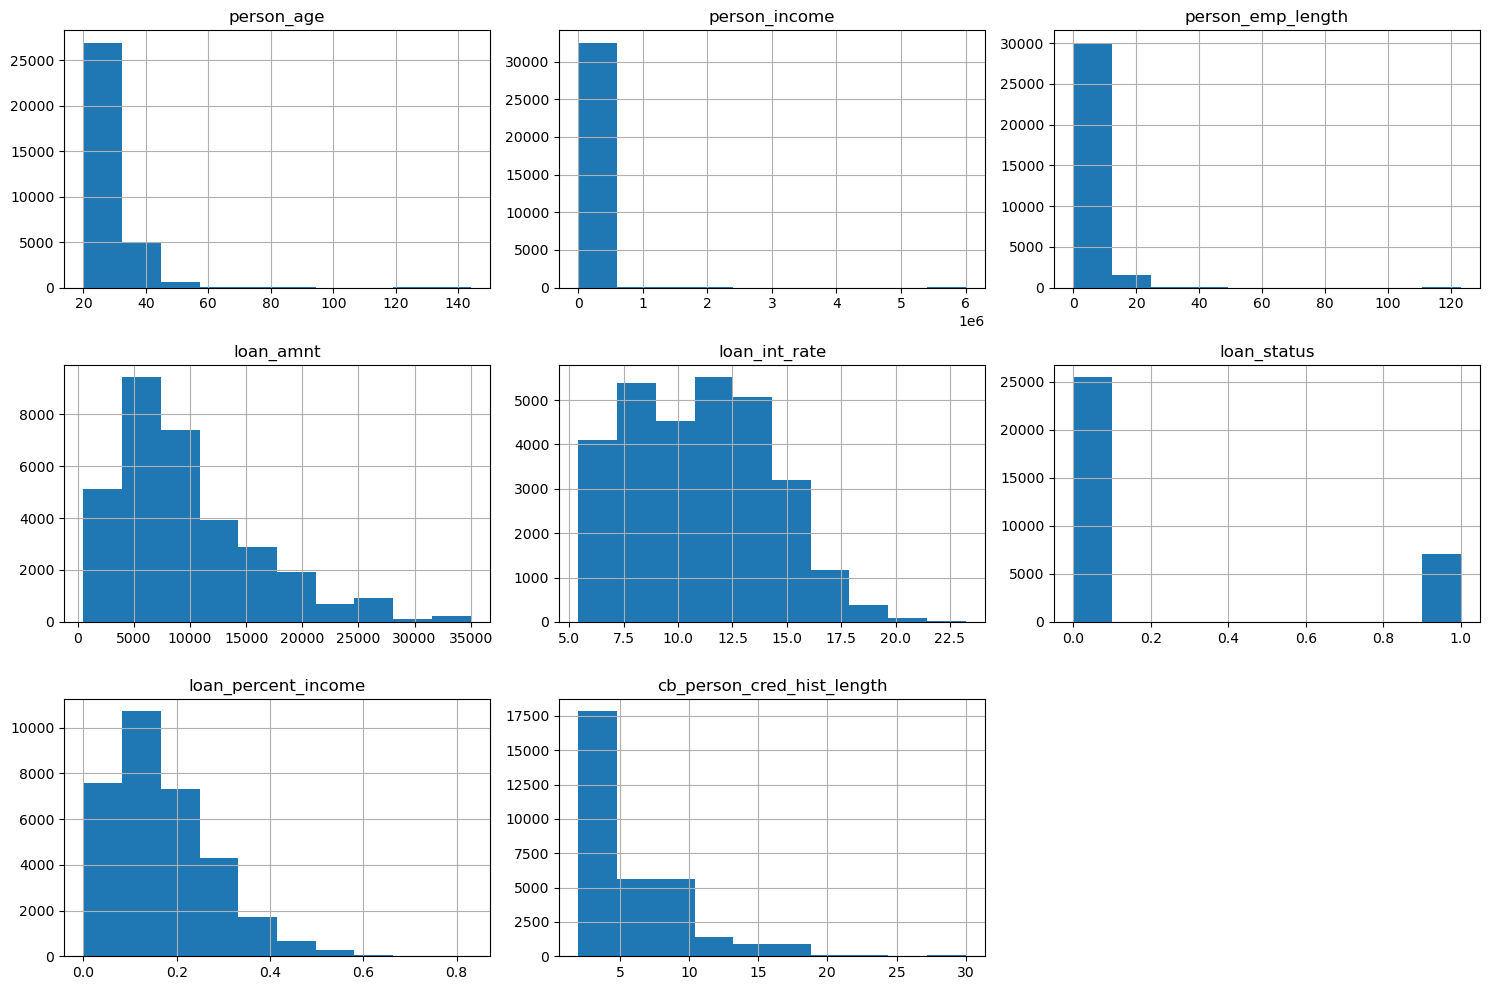

In [11]:
# Distribusi Awal Variavel Numerik
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

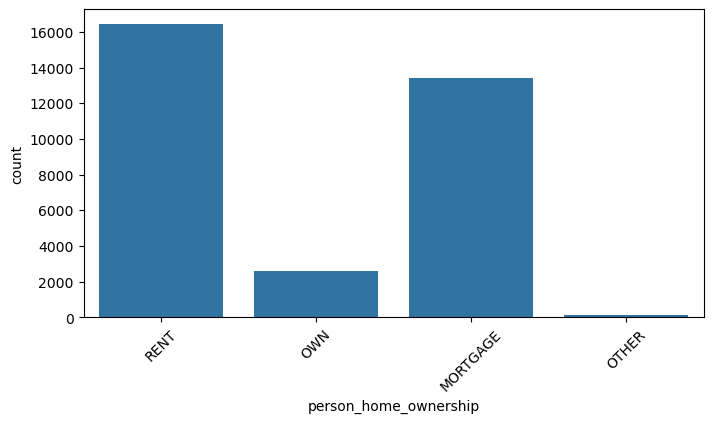

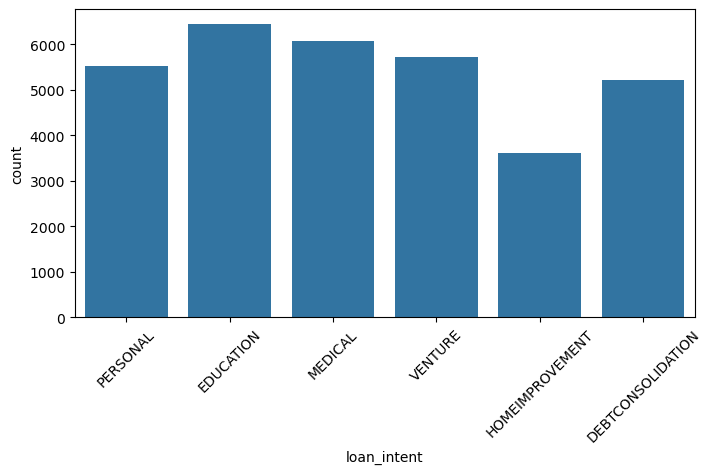

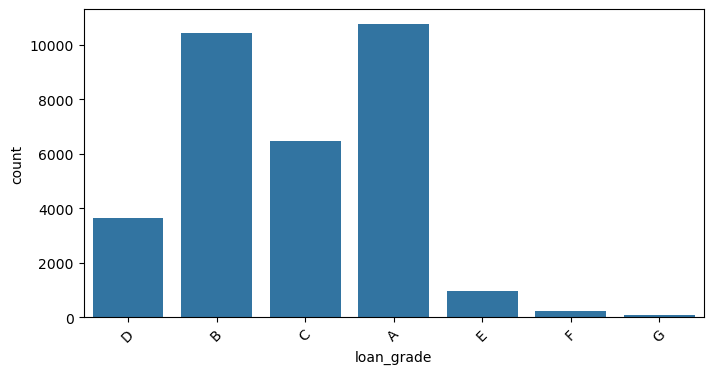

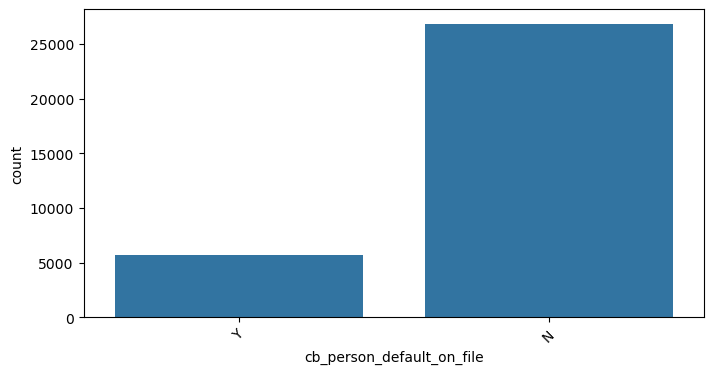

In [15]:
# Distribusi Variabel Kategorikal
for col in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)
    plt.show()

In [8]:
# Missing Value
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': round((missing / len(df)) * 100, 2)
})

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing Percentage (%)
person_emp_length,895,2.75
loan_int_rate,3116,9.56


In [9]:
# Duplicate
duplicate = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate}")

Jumlah data duplikat: 165


In [10]:
# unique value
for col in df.select_dtypes(include='object').columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== person_home_ownership =====
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

===== loan_intent =====
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

===== loan_grade =====
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

===== cb_person_default_on_file =====
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


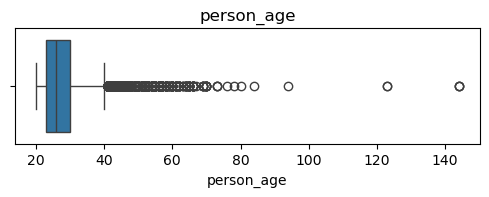

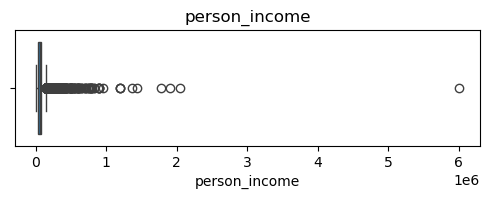

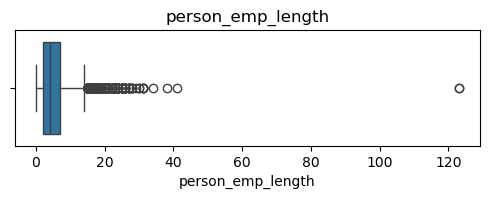

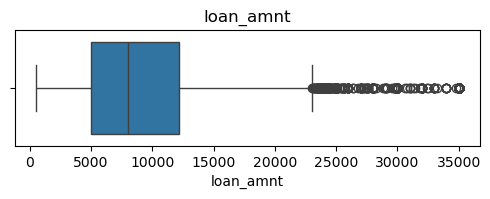

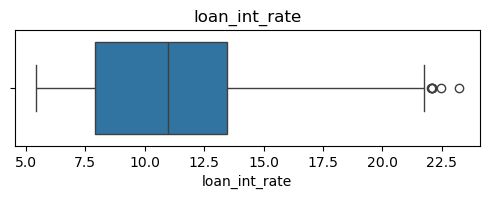

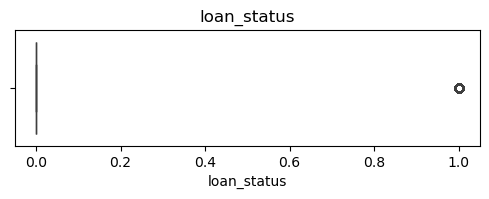

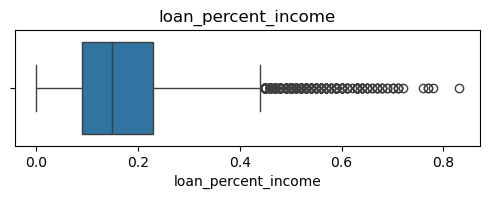

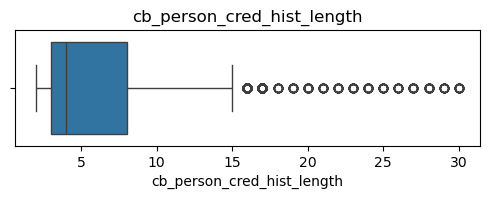

In [11]:
# Outlier
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(6,1.5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Keputusan Cleaning:

Missing person_emp_length	Isi dengan median

Missing loan_int_rate	Isi dengan median
Duplicate	Hapus

person_age = 144	Akan ditinjau dan dibersihkan

person_emp_length = 123	Akan ditinjau dan dibersihkan

Income Outlier	Dipertahankan

Loan Amount Outlier	Dipertahankan

Interest Rate Outlier	Dipertahankan

Credit History Outlier	Dipertahankan

In [12]:
# Cleaning Duplicate
df = df.drop_duplicates()

print(f'Jumlah data duplikat: {df.duplicated().sum()}')
print(f'Jumlah data setelah menghapus duplicate: {len(df)}')

Jumlah data duplikat: 0
Jumlah data setelah menghapus duplicate: 32416


In [13]:
# Isi Missing Value
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df['loan_int_rate'].median()
)

In [14]:
# Memberiskan outlier (dengan catatan lihat berapa jumlah data outliernya)

df[df['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [15]:
df[df['person_emp_length'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [16]:
# karena jumlah data outlier nya tergolong sedikit, maka menghapusnya hal wajar untuk dilakukan
df = df[(df['person_age'] < 100) & (df['person_emp_length'] < 100)]

# Temuan Awal

- Dataset terdiri dari 32.581 observasi.
- Terdapat missing value pada person_emp_length.
- Terdapat missing value pada loan_int_rate.
- Tidak ditemukan masalah pada tipe data.
- Ditemukan beberapa outlier yang akan diperiksa pada tahap cleaning.